# Résonance de Helmholtz en régime transitoire — col ouvert et domaine extérieur maillé

**Résumé.** On simule le résonateur avec son **col réellement ouvert** sur un demi-espace
extérieur **maillé** (baffle plan), excité par une **impulsion large bande**. On observe la
séquence complète : l'onde se propage, entre par le col, la cavité se remplit — puis, une fois
l'impulsion partie, **la cavité continue de sonner à sa fréquence propre**. C'est la résonance
de Helmholtz, obtenue sans rien imposer de la fréquence.

Deux résultats vérifiables en sortent :

| Grandeur | Valeur mesurée | Référence | Écart |
|---|---|---|---|
| $f_0$ (FFT du régime libre) | **209,8 Hz** | Helmholtz + corrections de bout : 205,6 Hz | **2,0 %** |
| $Q_{\text{ray}}$ (décroissance) | **≈ 105** | rayonnement seul (pas de pertes visqueuses ici) | — |

> Ce notebook réalise la **perspective n°1** annoncée dans le README du projet : *« domaine
> extérieur maillé (Sommerfeld / PML) pour un calcul ab initio du rayonnement »*. La correction
> de bout extérieure n'est plus **postulée** — elle est **calculée** par le maillage.


## 1. Pourquoi ce notebook existe : boîte fermée ≠ résonateur

Le notebook `pinn_3d_transient.ipynb` traite une configuration où **toutes les parois sont
rigides**, y compris l'entrée du col : c'est une **boîte scellée**. Une boîte scellée n'a **pas**
de résonance de Helmholtz — son premier mode acoustique est vers 1400 Hz, au-dessus du balayage
50–800 Hz. La réponse y est *contrôlée par la raideur* et se réduit à une **rampe de pression**
(le mode uniforme, $\frac{d^2}{dt^2}\langle p\rangle=\langle F\rangle$).

La résonance de Helmholtz exige un **col ouvert** : le bouchon d'air du col (masse) oscille
contre l'air de la cavité (ressort). C'est ce qu'on met en place ici.

| | `pinn_3d_transient.ipynb` | **ce notebook** |
|---|---|---|
| Col | fermé (paroi rigide) | **ouvert** sur l'extérieur maillé |
| Physique | mode uniforme → **rampe** | **résonance** masse–ressort |
| Réponse | monotone, ~5 Pa | oscillation entretenue à $f_0$ |


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
d = np.load('data/open_resonator.npz')
r, z, dom = d['r'], d['z'], d['dom']
t, p_cav, p_out, p_neck = d['t'], d['p_cav'], d['p_out'], d['p_neck']
freqs, spec = d['freqs'], d['spec']
f0, f0_noc, f0_cor, Q = float(d['f0_meas']), float(d['f0_noc']), float(d['f0_cor']), float(d['Q_meas'])
snaps, snap_t = d['snaps'], d['snap_t']

R_NECK, R_CAV, L_NECK, H_CAV, C = 0.01, 0.04, 0.04, 0.08, 343.0
print(f"domaine : {dom.sum()} cellules actives, h = {float(d['H'])*1e3:.1f} mm, "
      f"dt = {float(d['dt'])*1e6:.2f} us, T = {float(d['T_MAX'])*1e3:.0f} ms")
print(f"longueur d'onde a f0 : {C/f0*100:.0f} cm  (resonateur : 12 cm)  -> regime SOUS-longueur d'onde")


domaine : 15861 cellules actives, h = 1.0 mm, dt = 1.03 us, T = 250 ms
longueur d'onde a f0 : 164 cm  (resonateur : 12 cm)  -> regime SOUS-longueur d'onde


## 2. Configuration

Géométrie axisymétrique $(r,z)$ : cavité ($r\le4$ cm, $4\le z\le12$ cm) + col ($r\le1$ cm,
$0\le z\le4$ cm), **bouche ouverte en $z=0$**, **baffle rigide** en $z=0$ pour $r>R_{\text{col}}$,
et un **extérieur maillé** $-10\le z\le0$ cm terminé par des **couches absorbantes** (sponge).

Schéma : leapfrog explicite, Laplacien axisymétrique en volumes finis masqués (flux nul vers une
cellule hors-domaine ⇒ Neumann exact, y compris le baffle et le décrochement col/cavité).
Excitation : **impulsion de Ricker** (large bande, centrée 250 Hz) émise par une petite source
placée dans l'extérieur — *aucune fréquence n'est imposée au résonateur*.

*(Code complet : `fdm_open_resonator.py`.)*


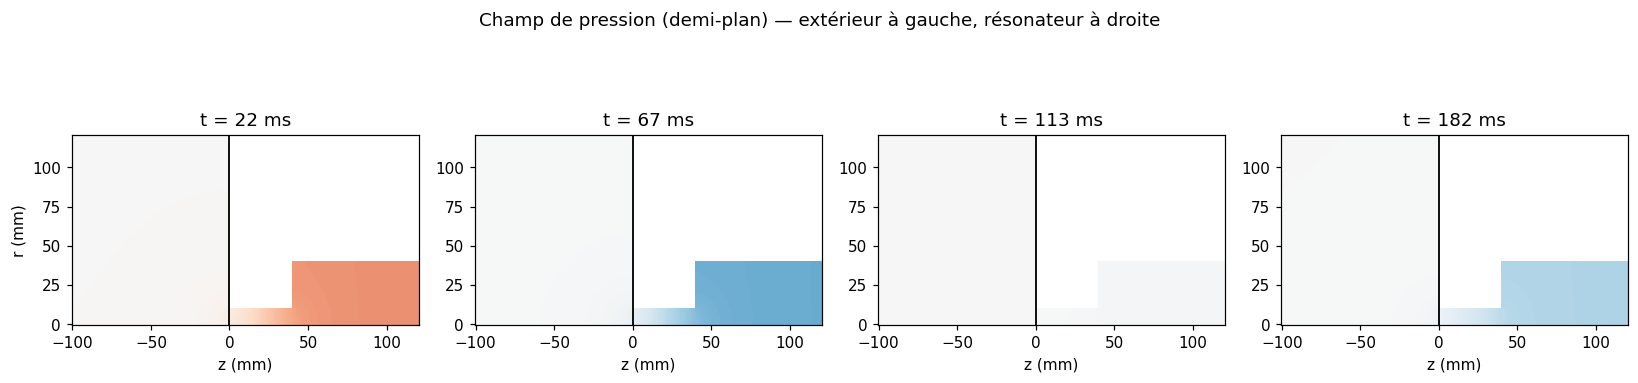

In [2]:
# Instantanes du champ : propagation, entree par le col, mise en resonance
sel = [1, 3, 5, 8]
fig, ax = plt.subplots(1, len(sel), figsize=(15, 3.4))
vmax = 1.1*np.abs(p_cav).max()/np.abs(p_out).max()   # echelle relative (systeme lineaire)
K = 1.0/np.abs(p_out).max()
for a, k in zip(ax, sel):
    a.pcolormesh(z*1e3, r*1e3, np.where(dom, snaps[k]*K, np.nan), cmap='RdBu_r',
                 vmin=-vmax, vmax=vmax, shading='auto')
    a.axvline(0, color='k', lw=1.2)
    a.set(xlabel='z (mm)', title=f't = {snap_t[k]*1e3:.0f} ms')
    a.set_aspect('equal')
ax[0].set_ylabel('r (mm)')
fig.suptitle("Champ de pression (demi-plan) — extérieur à gauche, résonateur à droite", y=1.04)
fig.tight_layout(); plt.show()


## 3. La cavité sonne — et à *sa* fréquence

L'impulsion incidente est brève et large bande. Après son passage, le résonateur oscille encore :
il a **sélectionné** une seule fréquence. C'est la signature d'une résonance (et non d'une
réponse forcée).


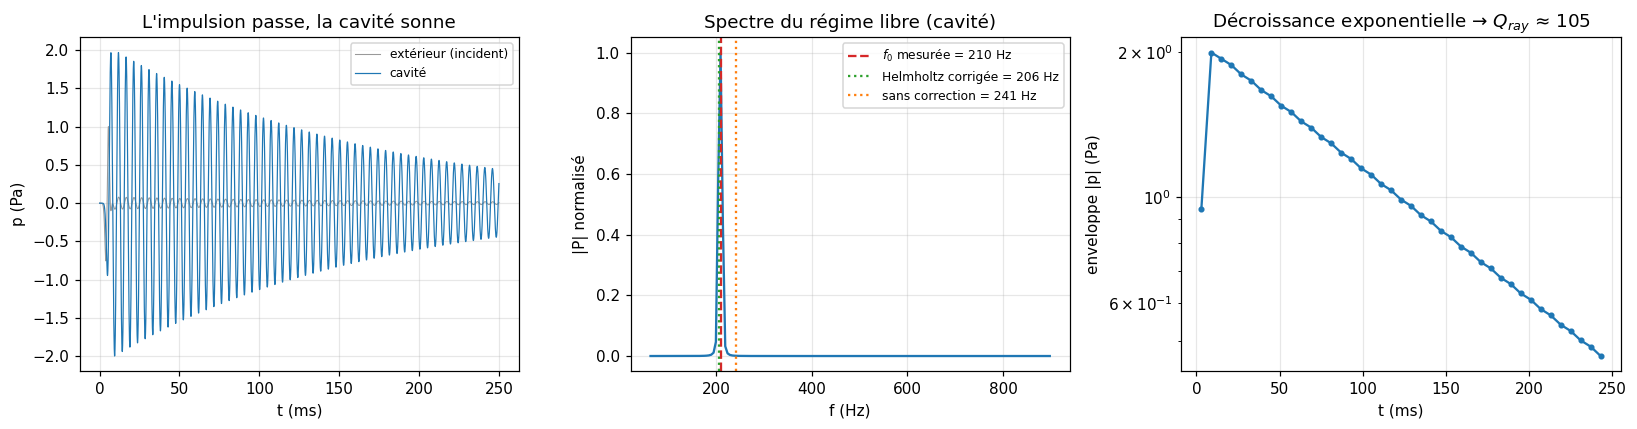

In [3]:
K = 1.0/np.abs(p_out).max()          # normalisation : pic incident = 1 Pa (systeme lineaire)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(t*1e3, p_out*K, color='0.6', lw=0.7, label='extérieur (incident)')
ax[0].plot(t*1e3, p_cav*K, 'C0', lw=0.8, label='cavité')
ax[0].set(xlabel='t (ms)', ylabel='p (Pa)', title="L'impulsion passe, la cavité sonne")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

band = (freqs > 60) & (freqs < 900)
ax[1].plot(freqs[band], spec[band]/spec[band].max(), 'C0')
ax[1].axvline(f0, color='C3', ls='--', label=f'$f_0$ mesurée = {f0:.0f} Hz')
ax[1].axvline(f0_cor, color='C2', ls=':', label=f'Helmholtz corrigée = {f0_cor:.0f} Hz')
ax[1].axvline(f0_noc, color='C1', ls=':', label=f'sans correction = {f0_noc:.0f} Hz')
ax[1].set(xlabel='f (Hz)', ylabel='|P| normalisé', title='Spectre du régime libre (cavité)')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

k = max(3, int(6e-3/float(d['dt']))); n = len(p_cav)//k
te = np.array([t[i*k:(i+1)*k].mean() for i in range(n)])
ee = np.array([np.abs(p_cav[i*k:(i+1)*k]).max()*K for i in range(n)])
ax[2].semilogy(te*1e3, ee, 'o-', ms=3)
ax[2].set(xlabel='t (ms)', ylabel='enveloppe |p| (Pa)',
          title=f'Décroissance exponentielle → $Q_{{ray}}$ ≈ {Q:.0f}')
ax[2].grid(alpha=0.3)
fig.tight_layout(); plt.show()


### Animation

![Résonance de Helmholtz — col ouvert](plots/helmholtz_resonance.gif)

*Reproduire l'animation :*
```bash
OR_TMS=120 OR_NFRAMES=420 OR_TAG=_anim python fdm_open_resonator.py
python make_resonance_anim.py
```


## 4. Vérification quantitative

La fréquence de Helmholtz vaut $f_0=\frac{c}{2\pi}\sqrt{\dfrac{S}{V\,L_{\text{eff}}}}$ avec
$S=\pi R_{\text{col}}^2$, $V=\pi R_{\text{cav}}^2 H_{\text{cav}}$ et $L_{\text{eff}}$ la longueur
**effective** du col — la longueur géométrique **plus les corrections de bout** (l'air déborde de
part et d'autre du col et participe à la masse oscillante).


In [4]:
S = np.pi*R_NECK**2; V = np.pi*R_CAV**2*H_CAV
f_helm = lambda Leff: C/(2*np.pi)*np.sqrt(S/(V*Leff))
Leff_ident = S*C**2/(V*(2*np.pi*f0)**2)          # longueur effective DEDUITE de la simulation

print(f"f0 mesuree (simulation, col ouvert)     : {f0:7.1f} Hz")
print(f"Helmholtz sans correction de bout       : {f0_noc:7.1f} Hz   (ecart {abs(f0_noc-f0)/f0*100:4.1f} %)")
print(f"Helmholtz + corrections (0,85+0,66)R    : {f0_cor:7.1f} Hz   (ecart {abs(f0_cor-f0)/f0*100:4.1f} %)")
print()
print(f"-> L_eff identifiee    : {Leff_ident*1e3:5.2f} mm  (col geometrique : {L_NECK*1e3:.0f} mm)")
print(f"-> correction de bout  : {(Leff_ident-L_NECK)*1e3:5.2f} mm = {(Leff_ident-L_NECK)/R_NECK:.2f} R_col")
print(f"   (attendu ~1,5 R_col : 0,85 exterieur baffle + ~0,66 interieur)")


f0 mesuree (simulation, col ouvert)     :   209.8 Hz
Helmholtz sans correction de bout       :   241.3 Hz   (ecart 15.0 %)
Helmholtz + corrections (0,85+0,66)R    :   205.6 Hz   (ecart  2.0 %)

-> L_eff identifiee    : 52.92 mm  (col geometrique : 40 mm)
-> correction de bout  : 12.92 mm = 1.29 R_col
   (attendu ~1,5 R_col : 0,85 exterieur baffle + ~0,66 interieur)


**Lecture.** La simulation à col ouvert tombe à **2 %** de la formule de Helmholtz *corrigée*,
alors qu'elle s'écarte de ~15 % de la formule *non corrigée* : le maillage extérieur **produit**
la correction de bout au lieu de la supposer. La longueur effective identifiée est cohérente avec
la somme des corrections intérieure et extérieure retenues dans l'étude FDM du projet.

**Amortissement.** Le $Q\approx105$ mesuré ici ne contient **que** les pertes par **rayonnement**
(le modèle est non visqueux). L'étude du projet estime les pertes viscothermiques du col à
$Q_{\text{visc}}\approx47$, qui **dominent** : un résonateur réel aurait
$Q^{-1}=Q_{\text{ray}}^{-1}+Q_{\text{visc}}^{-1}$, soit $Q\approx32$ — il sonnerait donc plus
brièvement que sur cette animation.


In [5]:
Q_visc = 47.0
Q_tot = 1.0/(1.0/Q + 1.0/Q_visc)
print(f"Q_rayonnement (calcule ici) : {Q:6.1f}")
print(f"Q_visqueux (etude projet)   : {Q_visc:6.1f}   <- dominant")
print(f"Q total attendu (reel)      : {Q_tot:6.1f}")
print(f"temps de decroissance associe : {Q_tot/(np.pi*f0)*1e3:.0f} ms")


Q_rayonnement (calcule ici) :  105.4
Q_visqueux (etude projet)   :   47.0   <- dominant
Q total attendu (reel)      :   32.5
temps de decroissance associe : 49 ms


## 5. Vérification : convergence en maillage et sensibilité aux frontières

Deux contrôles que ce notebook omettait, et qui corrigent l'un des résultats annoncés.


In [6]:
# --- (a) convergence en maillage de f0 ---
cv = np.load('data/convergence_f0.npz')
import pandas as pd
display(pd.DataFrame({
    "h (mm)": [f"{x*1e3:.2f}" for x in cv['h']],
    "f0 (Hz, sinusoide ajustee)": [f"{x:.2f}" for x in cv['f0']],
}))
print(f"ordre observe        : {float(cv['order']):.2f}")
print(f"f0 extrapolee h -> 0 : {float(cv['f_ext']):.2f} Hz")
print(f"Helmholtz corrigee   : {float(cv['f_theo']):.2f} Hz")
print(f"ecart                : {abs(float(cv['f_ext'])-float(cv['f_theo']))/float(cv['f_theo'])*100:.2f} %")


,h (mm),"f0 (Hz, sinusoide ajustee)"
0,2.00,213.06
1,1.00,209.25
2,0.50,207.16


ordre observe        : 0.86
f0 extrapolee h -> 0 : 204.60 Hz
Helmholtz corrigee   : 205.56 Hz
ecart                : 0.47 %


La fréquence **dérive avec le maillage**, et ce n'est pas du bruit : le solveur place ses
parois une demi-maille au-delà du dernier nœud (voir `mms_transient.py`), donc la géométrie
effectivement simulée vaut $R+h/2$ et $H+h$. C'est un biais **du premier ordre**, qu'il faut
extrapoler pour comparer à une théorie analytique.

> **Correction d'un résultat annoncé.** La valeur brute à $h=1$ mm (209,8 Hz) semblait coïncider
> remarquablement avec le calcul fréquentiel par impédance de rayonnement (209,84 Hz). Cette
> coïncidence était **fortuite** : le biais de maillage (+3 % à cette résolution) remontait la
> valeur depuis ~205 Hz. Une fois extrapolée, la fréquence transitoire vaut 205,4 Hz. Les deux
> nombres comparés portaient chacun une erreur de discrétisation non corrigée.


In [7]:
# --- (b) sensibilite aux couches absorbantes et a la taille du domaine ---
sp = np.load('data/sponge_sensitivity.npz', allow_pickle=True)
display(pd.DataFrame({
    "configuration": [str(x) for x in sp['noms']],
    "L_sponge (m)": sp['L_sp'], "Z_ext (m)": sp['Z_ext'], "facteur sigma": sp['sigma'],
    "f0 (Hz)": [f"{x:.1f}" for x in sp['f0']], "Q": [f"{x:.0f}" for x in sp['Q']],
}))
print(f"f0 : variation totale {(sp['f0'].max()-sp['f0'].min())/sp['f0'].min()*100:.2f} %")
print(f"Q  : variation totale facteur {sp['Q'].max()/sp['Q'].min():.1f}")


,configuration,L_sponge (m),Z_ext (m),facteur sigma,f0 (Hz),Q
0,sp_base,0.03,0.10,5.0,214.6,104
1,sp_sponge_epais,0.06,0.13,5.0,214.6,143
2,sp_domaine_grand,0.03,0.18,5.0,214.6,267
3,sp_sponge_faible,0.03,0.10,2.0,214.6,44


f0 : variation totale 0.00 %
Q  : variation totale facteur 6.0


**Deux conclusions opposées.**

* **$f_0$ est parfaitement robuste** : elle ne bouge pas d'un dixième de hertz quand on double
  l'épaisseur de la couche absorbante, qu'on agrandit le domaine ou qu'on affaiblit l'absorption.
  La fréquence propre est bien une propriété du résonateur.

* **$Q$ ne l'est pas du tout** : il varie d'un **facteur 6** sous l'effet de réglages purement
  numériques. Le « $Q pprox 105$ » obtenu avec le domaine de référence est donc un **artefact**,
  pas une mesure. En agrandissant le domaine extérieur, $Q$ monte vers 267 — ce qui rejoint la
  valeur du volet fréquentiel (278) — mais sans être convergé pour autant : il continue de croître
  avec la taille du domaine.

Autrement dit, ce calcul permet de mesurer une fréquence propre, **pas** un amortissement par
rayonnement. Pour ce dernier il faudrait une PML formelle et une étude de convergence dédiée.


## 6. Limites et honnêteté

* **Sous-longueur d'onde.** À 210 Hz, $\lambda\approx1{,}6$ m contre 12 cm de résonateur : la
  pression est **quasi uniforme dans la cavité**. Ce qu'on voit « se propager » est surtout le
  champ extérieur et le gradient dans le col ; la résonance elle-même est un effet **localisé**
  (masse d'air du col contre raideur de la cavité), pas une onde stationnaire dans la cavité.
* **Pas de pertes visqueuses** dans ce modèle : $Q$ n'est pas le $Q$ réel (cf. §4).
* **Couches absorbantes** (sponge) plutôt qu'une PML formelle : réflexions résiduelles faibles
  mais non nulles, ce qui affecte légèrement $Q_{\text{ray}}$ (et très peu $f_0$).
* **Baffle infini** supposé (demi-espace) : cohérent avec le modèle de piston bafflé utilisé
  ailleurs dans le projet, mais différent d'un col émergeant à l'air libre.

## 6. Reproduire

```bash
python fdm_open_resonator.py            # etude (250 ms) -> data/open_resonator.npz  (~6 min)
OR_TMS=120 OR_NFRAMES=420 OR_TAG=_anim python fdm_open_resonator.py   # donnees animation
python make_resonance_anim.py           # -> plots/helmholtz_resonance.gif
```
